# Optional synthetic pilot for the class LLM proposal
COMSCI/ECON 206 · Prof. Luyao Zhang

The sample homework reconstructs Jia et al.’s 22-LLM, 13-setting study. This notebook illustrates one cooperation game with synthetic choices; it is not the full study or an empirical replication. Its pedagogical precision rule is gamma**k, whereas the paper uses gamma*k.

[Open this notebook in Colab](https://colab.research.google.com/github/sunshineluyao/ps1-overleaf-template/blob/main/companion/notebooks/06_ps1_strategic_reasoning_demo.ipynb). Run all cells from a fresh CPU session. No LLM API call or human observation is used.


In [1]:
# Run this cell before importing scientific packages. CPU only; no API key.
import sys, subprocess, importlib.metadata as md
pins = {'numpy':'2.3.5', 'scipy':'1.17.0', 'matplotlib':'3.10.8', 'nashpy':'0.0.43'}
missing=[]
for package, version in pins.items():
    try: installed=md.version(package)
    except md.PackageNotFoundError: installed=None
    if installed != version: missing.append(f'{package}=={version}')
if missing: subprocess.check_call([sys.executable,'-m','pip','install','--quiet',*missing])
print('Tested with Python 3.12; this runtime:',sys.version.split()[0])
print({p:md.version(p) for p in pins})
# If Colab asks to restart after installation, restart the session and Run all.
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize':(7,3.6),'axes.spines.top':False,'axes.spines.right':False})


Tested with Python 3.12; this runtime: 3.12.13
{'numpy': '2.3.5', 'scipy': '1.17.0', 'matplotlib': '3.10.8', 'nashpy': '0.0.43'}


## Three connected questions
1. **Economics:** Which coordination incentives favor the efficient equilibrium?
2. **Computer science:** Can a reproducible bounded-reasoning model predict a distribution of choices?
3. **Behavioral science:** Can we distinguish reasoning depth from response precision?

The symmetric matrix is `[[8,0],[7,safe]]`, with column payoffs its transpose. At safe=5, the pure Nash equilibria are (Coordinate, Coordinate) and (Safe, Safe); both mix with probability 5/6 on Coordinate in the interior Nash equilibrium. The baseline matrix appears in Jia et al., Table 1(b). Payoff variations are original teaching adaptations.

In [2]:
"""Week 3 classroom models. Synthetic illustrations, not a paper replication."""
import math
import numpy as np

def nash_regret(A, B, x, y):
    """Maximum one-player gain, with row/column payoff matrices in the same orientation."""
    A, B, x, y = map(lambda v: np.asarray(v, dtype=float), (A,B,x,y))
    return max(0., float(np.max(A@y)-x@A@y), float(np.max(x@B)-x@B@y))

def coordination_matrix(safe=5.):
    if not 0 < safe < 8: raise ValueError('safe must be between 0 and 8')
    return np.array([[8.,0.],[7.,float(safe)]])

def logit_ch(tau=1.5, gamma=1.2, safe=5., K=16):
    """Truncated Poisson cognitive hierarchy with logit responses.
    Level 0 is uniform; level k responds to normalized lower-level beliefs.
    Precision is gamma**k. This is NOT a QRE fixed-point or a Nash solver.
    Returns population strategy, level strategies, omitted Poisson mass.
    """
    if not 0 <= tau <= 5 or not 1 <= gamma <= 2 or not 1 <= K <= 32:
        raise ValueError('Use 0<=tau<=5, 1<=gamma<=2, 1<=K<=32')
    A=coordination_matrix(safe)
    weights=np.array([math.exp(-tau)*tau**k/math.factorial(k) for k in range(K+1)])
    strategies=[np.array([.5,.5])]
    for k in range(1,K+1):
        belief=weights[:k] @ np.array(strategies) / weights[:k].sum()
        z=(gamma**k)*(A@belief); z-=z.max()
        response=np.exp(z); strategies.append(response/response.sum())
    levels=np.array(strategies)
    population=(weights/weights.sum())@levels
    return population,levels,max(0.,float(1-weights.sum()))

def entry_spne(fight=(-1.,-1.), accommodate=(1.,1.), out=(0.,2.)):
    """Return all backward-induction outcomes, preserving ties."""
    cont={'Fight':fight,'Accommodate':accommodate}; best=max(v[1] for v in cont.values()); result=[]
    for action,payoff in cont.items():
        if payoff[1] != best: continue
        entrant_best=max(out[0],payoff[0])
        for initial,p in [('Out',out),('In',payoff)]:
            if p[0]==entrant_best: result.append((initial,action,p))
    return result

import nashpy as nash
A=coordination_matrix();B=A.T
for x,y in nash.Game(A,B).support_enumeration():
    print('Nash:',np.round(x,6),np.round(y,6),'regret:',nash_regret(A,B,x,y))
p,levels,tail=logit_ch();print('Synthetic CH prediction:',p,'omitted Poisson mass:',tail)
assert np.isclose(p.sum(),1) and np.all(p>=0) and tail<1e-6
assert nash_regret(A,B,[5/6,1/6],[5/6,1/6])<1e-10


Nash: [1. 0.] [1. 0.] regret: 0.0
Nash: [0. 1.] [0. 1.] regret: 0.0
Nash: [0.833333 0.166667] [0.833333 0.166667] regret: 8.881784197001252e-16
Synthetic CH prediction: [0.14116121 0.85883879] omitted Poisson mass: 6.740163982499325e-13


The classroom model uses Poisson reasoning levels, uniform level 0, beliefs restricted to lower levels, and precision γ^k. We truncate at K=16 and renormalize. It is a **simplified logit cognitive hierarchy**, not a QRE fixed point, not a replication of the paper’s TQRE estimation, and not a claim that greater depth always improves outcomes.

K=16 vs K=24 maximum difference: 1.2827957274197388e-07


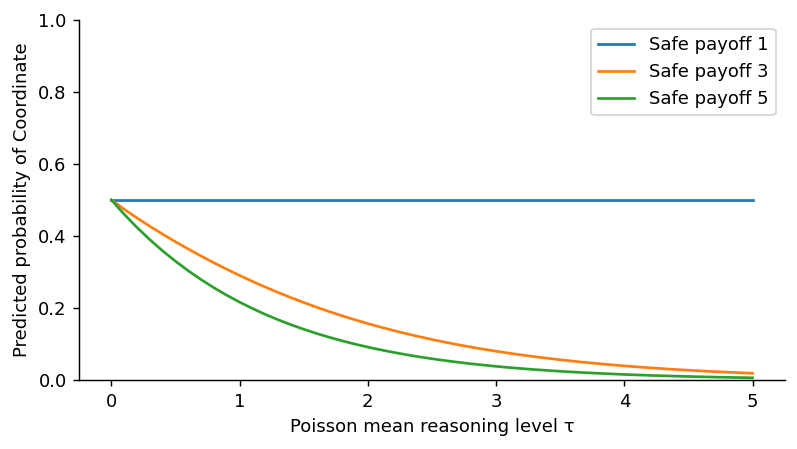

In [3]:
taus=np.linspace(0,5,51)
for safe in [1.,3.,5.]:
    values=[logit_ch(tau=t,gamma=1.2,safe=safe)[0][0] for t in taus]
    plt.plot(taus,values,label=f'Safe payoff {safe:g}')
plt.xlabel('Poisson mean reasoning level τ');plt.ylabel('Predicted probability of Coordinate');plt.ylim(0,1);plt.legend();plt.show()
# Numerical truncation sensitivity is distinct from behavioral validity.
a=logit_ch(tau=5,K=16)[0];b=logit_ch(tau=5,K=24)[0]
print('K=16 vs K=24 maximum difference:',np.max(np.abs(a-b)))
assert np.max(np.abs(a-b))<1e-4


In [4]:
# Parameter recovery exercise. Synthetic data only, fixed seed, no collected people/model data.
rng=np.random.default_rng(206)
settings=[1.,3.,5.]; true_tau,true_gamma=1.5,1.2
train=[];test=[]
for safe in settings:
    probability=logit_ch(true_tau,true_gamma,safe)[0][0]
    train.append(rng.binomial(1,probability,300));test.append(rng.binomial(1,probability,200))
def loss(tau,gamma,data):
    total=0
    for safe,y in zip(settings,data):
        p=np.clip(logit_ch(tau,gamma,safe)[0][0],1e-9,1-1e-9)
        total-=np.sum(y*np.log(p)+(1-y)*np.log(1-p))
    return total/sum(map(len,data))
candidates=[(loss(t,g,train),t,g) for t in np.arange(.5,3.01,.25) for g in np.arange(1.,1.81,.1)]
_,t_hat,g_hat=min(candidates)
print('Grid estimate:',round(t_hat,3),round(g_hat,3))
print('Held-out synthetic log loss:',round(loss(t_hat,g_hat,test),4))
print('Uniform baseline log loss:',round(float(np.log(2)),4))
# A single binary game identifies only one choice probability, not generally two latent parameters.
# Multiple games help, but this exercise does not prove identification or generalization.
import json
report={'data_status':'synthetic classroom illustration','seed':206,'train_per_game':300,'test_per_game':200,'safe_payoffs':settings,'true_tau':true_tau,'true_gamma':true_gamma,'fit_tau':float(t_hat),'fit_gamma':float(g_hat),'heldout_log_loss':loss(t_hat,g_hat,test),'uniform_log_loss':float(np.log(2)),'baseline_probability_coordinate':float(logit_ch()[0][0])}
from pathlib import Path
Path('ps1_demo_results.json').write_text(json.dumps(report,indent=2))
print(json.dumps(report,indent=2))


Grid estimate: 1.75 1.1
Held-out synthetic log loss: 0.5367
Uniform baseline log loss: 0.6931
{
  "data_status": "synthetic classroom illustration",
  "seed": 206,
  "train_per_game": 300,
  "test_per_game": 200,
  "safe_payoffs": [
    1.0,
    3.0,
    5.0
  ],
  "true_tau": 1.5,
  "true_gamma": 1.2,
  "fit_tau": 1.75,
  "fit_gamma": 1.1,
  "heldout_log_loss": 0.5367242798940238,
  "uniform_log_loss": 0.6931471805599453,
  "baseline_probability_coordinate": 0.1411612106606377
}


## Your experiment
Add one held-out payoff setting, compare a misspecified model, and explain what real evidence would be needed. Keep the paper, notebook, and interactive game on the same model. Report expected results separately from these synthetic diagnostics.

Before using AI assistance, write your own prediction. Disclose any drafting or debugging help and verify every claim.

## Sources and scope
[Jia et al., NeurIPS 2025 main conference](https://papers.nips.cc/paper_files/paper/2025/hash/54b13427fc2c9180f85c3d76cdcf076e-Abstract-Conference.html); [Camerer, Ho & Chong 2004](https://doi.org/10.1162/0033553041502225); [Nash 1950](https://doi.org/10.1073/pnas.36.1.48). The proposal and code are instructor-facing course exemplars, not the original authors’ proposal or released implementation.